In [2]:
# 1. Generate Synthetic Imbalanced Fraud Dataset
from sklearn.datasets import make_classification

X_raw, y_raw = make_classification(
    n_samples=50000, n_features=30, n_informative=20, 
    weights=[0.998, 0.002], random_state=42
)

feature_names = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']
df = pd.DataFrame(X_raw, columns=feature_names)
df['Class'] = y_raw

print("Synthetic Dataset Created Successfully!")
print(f"Legitimate (0): {sum(df['Class']==0)}")
print(f"Fraudulent (1): {sum(df['Class']==1)}")

Synthetic Dataset Created Successfully!
Legitimate (0): 49641
Fraudulent (1): 359


--- MODEL EVALUATION METRICS ---

================ Logistic Regression (Weighted) ================
ROC-AUC Score          : 0.7310
PR-AUC (Avg Precision) : 0.1458

Classification Report:
              precision    recall  f1-score   support

           0     0.9946    0.1319    0.2329      9849
           1     0.0166    0.9536    0.0326       151

    accuracy                         0.1443     10000
   macro avg     0.5056    0.5428    0.1327     10000
weighted avg     0.9799    0.1443    0.2299     10000


================ Random Forest (Weighted) ================
ROC-AUC Score          : 0.7518
PR-AUC (Avg Precision) : 0.3632

Classification Report:
              precision    recall  f1-score   support

           0     0.9891    0.9981    0.9936      9849
           1     0.6935    0.2848    0.4038       151

    accuracy                         0.9873     10000
   macro avg     0.8413    0.6414    0.6987     10000
weighted avg     0.9847    0.9873    0.9847     10000



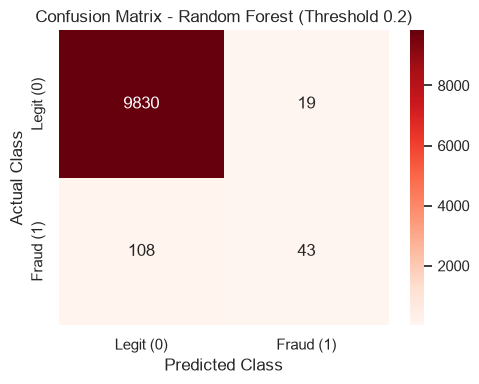

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

sns.set_theme(style="whitegrid")

# 1. Generate Synthetic Imbalanced Dataset
X_raw, y_raw = make_classification(
    n_samples=50000, n_features=30, n_informative=20, 
    weights=[0.99, 0.01], random_state=42
)
feature_names = [f'V{i}' for i in range(1, 29)] + ['Amount', 'Time']
df = pd.DataFrame(X_raw, columns=feature_names)
df['Class'] = y_raw

# 2. Scale Features (Safely create new columns without dropping originals in-place)
scaler = RobustScaler()
X = df.drop(columns=['Class']).copy()
y = df['Class']

X['scaled_amount'] = scaler.fit_transform(X[['Amount']])
X['scaled_time'] = scaler.fit_transform(X[['Time']])
X = X.drop(columns=['Time', 'Amount'])

# 3. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 4. Model Training & Evaluation with Lower Decision Threshold
models = {
    "Logistic Regression (Weighted)": LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    "Random Forest (Weighted)": RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42, n_jobs=-1)
}

print("--- MODEL EVALUATION METRICS ---")
for name, model in models.items():
    model.fit(X_train, y_train)
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= 0.2).astype(int)  # Lower threshold to detect rare fraud cases
    
    roc_auc = roc_auc_score(y_test, probs)
    pr_auc = average_precision_score(y_test, probs)
    
    print(f"\n================ {name} ================")
    print(f"ROC-AUC Score          : {roc_auc:.4f}")
    print(f"PR-AUC (Avg Precision) : {pr_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, preds, digits=4, zero_division=0))

# 5. Plot Confusion Matrix
rf_model = models["Random Forest (Weighted)"]
rf_probs = rf_model.predict_proba(X_test)[:, 1]
rf_preds = (rf_probs >= 0.2).astype(int)

plt.figure(figsize=(5, 4))
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['Legit (0)', 'Fraud (1)'],
            yticklabels=['Legit (0)', 'Fraud (1)'])
plt.title('Confusion Matrix - Random Forest (Threshold 0.2)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.tight_layout()
plt.show()